  Cargando benign_full.csv ... 1,098,126 filas

█████████████████████████████████████████████████████████████████
  ANÁLISIS COMPLETO — Telnet
█████████████████████████████████████████████████████████████████

  ── Conteos ──────────────────────────────────────────
  Total filas:           1,098,126
  Valores válidos:       1,098,126  (100.0000%)
  Valores nulos:                 0  (0.0000%)
  Valores = 0:           1,098,126  (100.0000%)
  Valores ≠ 0:                   0  (0.0000%)
  Valores únicos:                1

  ── Estadísticas ─────────────────────────────────────
  Media:                  0.000000
  Desv. estándar:         0.000000
  Mínimo:                 0.000000
  P25:                    0.000000
  Mediana (P50):          0.000000
  P75:                    0.000000
  Máximo:                 0.000000
  Rango:                  0.000000
  Varianza:               0.000000

  ── Distribución de valores únicos ───────────────────
  Valor   0.0000 →    1,098,126 registros  (100

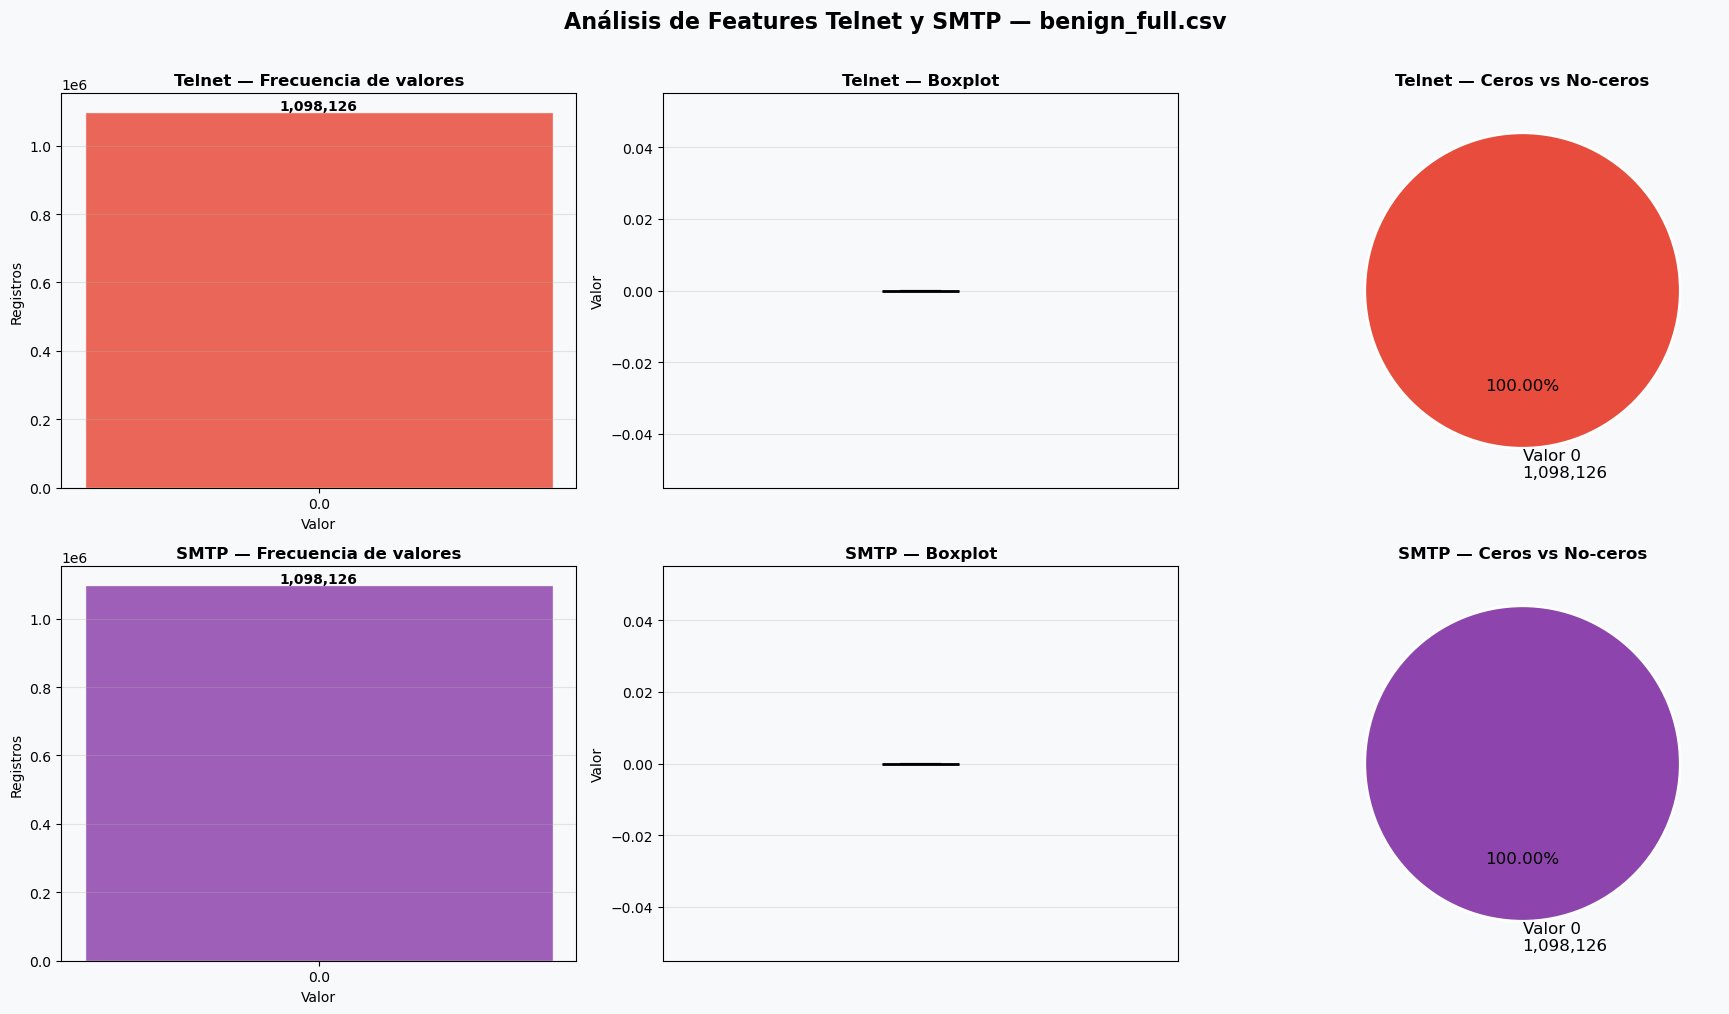


  ✓ analisis_telnet_smtp.png guardado


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PART_DIR = Path(r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\particiones")
GRAF_DIR = PART_DIR.parent / "graficas_benign_full"
GRAF_DIR.mkdir(parents=True, exist_ok=True)

print("  Cargando benign_full.csv ...", end=" ", flush=True)
df = pd.read_csv(PART_DIR / "benign_full.csv")
print(f"{df.shape[0]:,} filas")

TARGETS = ['Telnet', 'SMTP']
total   = len(df)

for feat in TARGETS:
    col = df[feat]

    print(f"\n{'█'*65}")
    print(f"  ANÁLISIS COMPLETO — {feat}")
    print(f"{'█'*65}")

    # ── 1. CONTEOS BÁSICOS ────────────────────────────────────────
    validos  = col.notna().sum()
    nulos    = total - validos
    ceros    = (col == 0).sum()
    no_ceros = (col != 0).sum()
    unicos   = col.nunique()

    print(f"\n  ── Conteos ──────────────────────────────────────────")
    print(f"  Total filas:        {total:>12,}")
    print(f"  Valores válidos:    {validos:>12,}  ({validos/total*100:.4f}%)")
    print(f"  Valores nulos:      {nulos:>12,}  ({nulos/total*100:.4f}%)")
    print(f"  Valores = 0:        {ceros:>12,}  ({ceros/total*100:.4f}%)")
    print(f"  Valores ≠ 0:        {no_ceros:>12,}  ({no_ceros/total*100:.4f}%)")
    print(f"  Valores únicos:     {unicos:>12,}")

    # ── 2. ESTADÍSTICAS ───────────────────────────────────────────
    print(f"\n  ── Estadísticas ─────────────────────────────────────")
    print(f"  Media:              {col.mean():>12.6f}")
    print(f"  Desv. estándar:     {col.std():>12.6f}")
    print(f"  Mínimo:             {col.min():>12.6f}")
    print(f"  P25:                {col.quantile(0.25):>12.6f}")
    print(f"  Mediana (P50):      {col.median():>12.6f}")
    print(f"  P75:                {col.quantile(0.75):>12.6f}")
    print(f"  Máximo:             {col.max():>12.6f}")
    print(f"  Rango:              {col.max()-col.min():>12.6f}")
    print(f"  Varianza:           {col.var():>12.6f}")

    # ── 3. DISTRIBUCIÓN DE VALORES ────────────────────────────────
    print(f"\n  ── Distribución de valores únicos ───────────────────")
    vc = col.value_counts().sort_index()
    for val, cnt in vc.items():
        print(f"  Valor {val:>8.4f} → {cnt:>12,} registros  ({cnt/total*100:.4f}%)")

    # ── 4. CONCLUSIÓN ─────────────────────────────────────────────
    print(f"\n  ── Conclusión ───────────────────────────────────────")
    if unicos == 1:
        print(f"  ⚠  FEATURE CONSTANTE: siempre vale {col.iloc[0]}")
        print(f"  ⚠  No aporta información al modelo → candidata a eliminar")
    elif no_ceros / total < 0.001:
        print(f"  ⚠  Casi constante: solo {no_ceros} registros ≠ 0 ({no_ceros/total*100:.4f}%)")
    else:
        print(f"  ✓  Feature con variabilidad: {unicos} valores distintos")

# ── GRÁFICAS ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle('Análisis de Features Telnet y SMTP — benign_full.csv',
             fontsize=16, fontweight='bold', y=1.01)

COLORES = {'Telnet': '#e74c3c', 'SMTP': '#8e44ad'}

for row, feat in enumerate(TARGETS):
    col    = df[feat]
    color  = COLORES[feat]
    vc     = col.value_counts().sort_index()

    # — Gráfica 1: distribución de valores (bar) —
    ax = axes[row, 0]
    ax.set_facecolor('#f8f9fa')
    ax.bar([str(round(v, 4)) for v in vc.index], vc.values,
           color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{feat} — Frecuencia de valores', fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Registros')
    for i, (v, c) in enumerate(zip(vc.index, vc.values)):
        ax.text(i, c + total*0.005, f'{c:,}', ha='center', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # — Gráfica 2: boxplot —
    ax = axes[row, 1]
    ax.set_facecolor('#f8f9fa')
    ax.boxplot(col.values, vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5),
               flierprops=dict(marker='o', markersize=3, alpha=0.3))
    ax.set_title(f'{feat} — Boxplot', fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.3)

    # — Gráfica 3: pie ceros vs no-ceros —
    ax = axes[row, 2]
    ax.set_facecolor('#f8f9fa')
    ceros    = (col == 0).sum()
    no_ceros = (col != 0).sum()
    if no_ceros == 0:
        ax.pie([ceros], labels=[f'Valor 0\n{ceros:,}'],
               colors=[color], autopct='%1.2f%%',
               startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 2},
               textprops={'fontsize': 12})
    else:
        ax.pie([ceros, no_ceros],
               labels=[f'Ceros\n{ceros:,}', f'No ceros\n{no_ceros:,}'],
               colors=[color, '#2ecc71'],
               autopct='%1.4f%%', startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 2},
               textprops={'fontsize': 11})
    ax.set_title(f'{feat} — Ceros vs No-ceros', fontweight='bold')

plt.tight_layout()
plt.savefig(GRAF_DIR / 'analisis_telnet_smtp.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  ✓ analisis_telnet_smtp.png guardado")


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import gc

# ════════════════════════════════════════════════════════════════
# CONFIGURACIÓN
# ════════════════════════════════════════════════════════════════
CSV_ROOT = Path(r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\CSV\CSV")
FEATURES_REVISAR = ['Telnet', 'SMTP']

assert CSV_ROOT.exists(), f"No encontrado: {CSV_ROOT}"

# Mapear clases de ataque
clases_ataque = sorted([
    c for c in CSV_ROOT.iterdir()
    if c.is_dir() and 'Benign' not in c.name
])

print("=" * 65)
print("  VERIFICACIÓN — Telnet y SMTP en datos de ATAQUE")
print("=" * 65)
print(f"  Clases a revisar: {len(clases_ataque)}")
print()

# ════════════════════════════════════════════════════════════════
# REVISAR CADA CLASE DE ATAQUE
# ════════════════════════════════════════════════════════════════
resumen = {}

for clase_dir in clases_ataque:
    clase = clase_dir.name
    archivos = sorted(clase_dir.glob("*.csv"))

    total_filas   = 0
    no_cero_telnet = 0
    no_cero_smtp   = 0

    for archivo in archivos:
        try:
            df = pd.read_csv(archivo, usecols=FEATURES_REVISAR)
            total_filas    += len(df)
            no_cero_telnet += (df['Telnet'] != 0).sum()
            no_cero_smtp   += (df['SMTP']   != 0).sum()
            del df
        except Exception as e:
            print(f"  ⚠ Error en {archivo.name}: {e}")

    resumen[clase] = {
        'filas':   total_filas,
        'telnet':  int(no_cero_telnet),
        'smtp':    int(no_cero_smtp),
    }

    tiene = []
    if no_cero_telnet > 0: tiene.append(f"Telnet≠0: {no_cero_telnet:,}")
    if no_cero_smtp   > 0: tiene.append(f"SMTP≠0: {no_cero_smtp:,}")
    estado = "  ✓ ambas=0" if not tiene else f"  ⚠ {', '.join(tiene)}"

    print(f"  {clase:40}  {total_filas:>10,} filas  {estado}")
    gc.collect()

# ════════════════════════════════════════════════════════════════
# RESUMEN FINAL
# ════════════════════════════════════════════════════════════════
total_telnet = sum(v['telnet'] for v in resumen.values())
total_smtp   = sum(v['smtp']   for v in resumen.values())
total_filas  = sum(v['filas']  for v in resumen.values())

clases_telnet = [k for k, v in resumen.items() if v['telnet'] > 0]
clases_smtp   = [k for k, v in resumen.items() if v['smtp']   > 0]

print()
print("=" * 65)
print("  RESUMEN FINAL")
print("=" * 65)
print(f"  Total filas de ataque revisadas: {total_filas:,}")
print()
print(f"  Telnet ≠ 0 en ataques:")
print(f"    Total registros: {total_telnet:,}")
print(f"    Clases afectadas: {len(clases_telnet)}")
if clases_telnet:
    for c in clases_telnet:
        print(f"      → {c}: {resumen[c]['telnet']:,} registros")
else:
    print(f"    Ninguna clase tiene Telnet ≠ 0")

print()
print(f"  SMTP ≠ 0 en ataques:")
print(f"    Total registros: {total_smtp:,}")
print(f"    Clases afectadas: {len(clases_smtp)}")
if clases_smtp:
    for c in clases_smtp:
        print(f"      → {c}: {resumen[c]['smtp']:,} registros")
else:
    print(f"    Ninguna clase tiene SMTP ≠ 0")

print()
print("  DECISIÓN FINAL:")
if total_telnet == 0 and total_smtp == 0:
    print("  ✓ Telnet y SMTP son 0 en TODOS los datos (benigno + ataque)")
    print("  ✓ Eliminación completamente justificada")
    print("  ✓ No hay información que se pierda al quitarlas")
else:
    print("  ⚠ Alguna feature tiene valores ≠ 0 en ataques")
    print("  ⚠ Considerar mantenerlas o usar tratamiento especial")

  VERIFICACIÓN — Telnet y SMTP en datos de ATAQUE
  Clases a revisar: 33

  Backdoor_Malware                               3,218 filas    ✓ ambas=0
  BrowserHijacking                               5,859 filas    ✓ ambas=0
  CommandInjection                               5,409 filas    ✓ ambas=0
  DDoS-ACK_Fragmentation                       285,075 filas    ⚠ Telnet≠0: 181, SMTP≠0: 184
  DDoS-HTTP_Flood                               28,790 filas    ✓ ambas=0
  DDoS-ICMP_Flood                            7,200,501 filas    ✓ ambas=0
  DDoS-ICMP_Fragmentation                      452,490 filas    ✓ ambas=0
  DDoS-PSHACK_FLOOD                          4,094,772 filas    ⚠ Telnet≠0: 6,115, SMTP≠0: 6,132
  DDoS-RSTFINFLOOD                           4,045,279 filas    ⚠ Telnet≠0: 6,044, SMTP≠0: 6,048
  DDoS-SlowLoris                                23,426 filas    ✓ ambas=0
  DDoS-SYN_Flood                             4,059,179 filas    ⚠ Telnet≠0: 6,040, SMTP≠0: 6,032
  DDoS-SynonymousIP_Floo